Instruct the notebook to draw plot graphics inline:

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
import sys
import os
import inspect
import datetime
import logging

In [3]:
# import pytz
# local_tz = pytz.timezone('US/Eastern')  # Adjust for your local timezone, America/New_York
import zoneinfo
local_tz = zoneinfo.ZoneInfo(key='US/Eastern')

In [4]:
import math
import numpy as np
from numpy.typing import NDArray
import pandas as pd
import ipywidgets as widgets
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import pathlib
import inspect

In [5]:
import more_itertools as mit
from more_itertools import windowed
from itertools import pairwise

In [6]:
# to import local code
# https://stackoverflow.com/questions/61058798/python-relative-import-in-jupyter-notebook
# https://stackoverflow.com/questions/34478398/import-local-function-from-a-module-housed-in-another-directory-with-relative-im


# parent_dir = os.path.abspath('..\..')
# if parent_dir not in sys.path:
#     # sys.path.append(parent_dir)
#     sys.path.insert(0, parent_dir)
#     print(f"{parent_dir} added to sys.path")


In [ ]:
search_dirs = ['../..', '../../..', '..', '../../../jj625/mplfinance/src']
pkg_needed = ['mplfinance', 'eventkit', 'ib_insync']
pkg_dirs = {}

for pkg in pkg_needed:
    for dir in search_dirs:
        potential_dir = pathlib.Path(dir, pkg).resolve()
        if potential_dir.exists() and potential_dir.is_dir():
            pkg_dirs[pkg] = potential_dir
            break

for pkg, pkg_dir in pkg_dirs.items():
    if str(pkg_dir) not in sys.path:
        sys.path.insert(0, str(pkg_dir))
        print(f"{pkg_dir} added to sys.path")

missing_pkgs = [pkg for pkg in pkg_needed if pkg not in pkg_dirs]
if missing_pkgs:
    print(f"Expected directories not found for: {', '.join(missing_pkgs)}")


In [ ]:
import mplfinance as mpf
print(f"module loaded: {inspect.getfile(mpf)}")
import ib_insync
print(f"module loaded: {inspect.getfile(ib_insync)}")

In [9]:
# util.logToConsole(logging.INFO)
sym = 'AVGO'

date = f'{datetime.datetime.now()+datetime.timedelta(days=0):%Y%m%d}'
filename = f'{sym}_1m_{date}.csv'
load_from_csv = True
bars = None
if load_from_csv:
    bars_df = pd.read_csv(rf'.\data\{filename}', parse_dates=['date'])
if 'open_' in bars_df.columns:
    bars_df.rename(columns={'open_': 'open'}, inplace=True)
# util.logToConsole(logging.INFO)
bars_df['log_avg'] = np.log(bars_df['average'])

In [24]:
# Filter bars_df for the time range from 9:30am to 4:00pm
m1 = (bars_df['date'].dt.time >= datetime.time(9, 30)) & (bars_df['date'].dt.time < datetime.time(16, 0))
m2 = (bars_df['date'].dt.time >= datetime.time(9, 30)) & (bars_df['date'].dt.time <= datetime.time(12, 5))
# filtered_bars_df = bars_df[m1]

# Create the date range index
# idx = pd.date_range(start=filtered_bars_df['date'].min(), end=filtered_bars_df['date'].max(), freq='1min')


In [ ]:
from collections.abc import Iterable
def all_same_sign(iterable):
    if not isinstance(iterable, Iterable):
        return False
    first_sign = None
    for num in iterable:
        if num == 0:
            continue
        sign = num > 0
        if first_sign is None:
            first_sign = sign
        elif sign != first_sign:
            return False
    return True

# # Example usage
# print(all_same_sign([]))  # True
# print(all_same_sign([0]))  # True
# print(all_same_sign([1.0, 2.0, 3.0]))  # True
# print(all_same_sign([-1.0, -2.0, -3.0]))  # True
# print(all_same_sign([1.0, -2.0, 3.0]))  # False
# print(all_same_sign([0.0, 0.0, 0.0]))  # True
# print(all_same_sign([0.0, 1.0, 2.0]))  # True
# print(all_same_sign([0.0, -1.0, -2.0]))  # True

In [ ]:
sigma = 3
N = 4000  # Set the maximum number of iterations
df = bars_df[m1]
for m, i in enumerate(range(1, len(df) + 1)):
    if m >= N:
        break
    rolling_window = df['average'][:i]
    last_price = rolling_window.iloc[-1]
    date_rolling_window = df['date'][:i]
    der1_3sigma = gaussian_filter1d(rolling_window, sigma=3, order=1, mode='nearest')
    der1_16sigma = gaussian_filter1d(rolling_window, sigma=16, order=1, mode='nearest')
    der1_norm = np.linalg.norm(der1_3sigma)
    der1_norm5 = np.linalg.norm(der1_3sigma[-10:])
    direction_3sigma = "positive" if der1_3sigma[-1] > 0 else "negative"
    direction_16sigma = "positive" if der1_16sigma[-1] > 0 else "negative"
    # print(f"Direction: {direction}")
    # der2 = gaussian_filter1d(rolling_window, sigma=sigma, order=2, mode='nearest')
    timestamp = date_rolling_window.iloc[-1]
    print(i, f"{timestamp:%H:%M:%S}", len(rolling_window), rolling_window.iloc[-1], f"{der1_3sigma[-1]:.5f}", f"{der1_3sigma[-1]/last_price:.5f}"
          , f"{der1_16sigma[-1]:.5f}", f"{der1_16sigma[-1]/last_price:.5f}", direction_3sigma, all_same_sign(der1_3sigma[-5:]), direction_16sigma, all_same_sign(der1_16sigma[-5:]))

In [ ]:
mpf.original_flavor = True
df=bars_df[m1].set_index('date').loc[:, ['open', 'high', 'low', 'close', 'volume']]
base = df['close'].iloc[0]
df[['open', 'high', 'low', 'close']] = df[['open', 'high', 'low', 'close']].apply(lambda x: (x / base) - 1)
df['date'] = df.index

ref = base
def price2pct(px):
    return (px - ref) / ref
def pct2price(pct):
    return pct * ref + ref
fig, axs = mpf.plot(df, style='charles', figratio=(5,1), returnfig=True)
# axs[0].set_facecolor('#4C4C4C')
secax = axs[0].secondary_yaxis('left', functions=(pct2price, price2pct))
axs[0].yaxis.set_major_locator(ticker.MultipleLocator(0.01))
axs[0].yaxis.set_major_locator(ticker.MultipleLocator(0.006))
axs[0].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=2))
axs[0].xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.show()

In [72]:
def extract_field_as_array(group, field_name):
    return np.array([getattr(item, field_name) for item in group])

# # Example usage
# a_arr = extract_field_as_array(group, 'a')
# b_arr = extract_field_as_array(group, 'b')
# c_arr = extract_field_as_array(group, 'c')

# print("a_arr:", a_arr)
# print("b_arr:", b_arr)
# print("c_arr:", c_arr)


In [ ]:
def load_data(sym, file_pattern='*_1m_*.csv', data_dir='.'):
    p = pathlib.Path(data_dir)
    files = list(p.glob(file_pattern))
    print(files)
    df = pd.read_csv(files[0], parse_dates=['date'])
    # df.index = pd.to_datetime(df['date'])
    # df = df.drop(columns=['date'])
    return df
df_spy = load_data('SPY', 'SPY_1m_241130*.csv')

In [77]:
def df_to_csv(df, sym):
    filename = f'{sym}_1m_{datetime.datetime.now():%y%m%d_%H%M%S}.csv'
    df.to_csv(filename, index=False)
    print(f'{filename} saved')

In [78]:
def df_add_high_minus_low(df):
    df['high_minus_low'] = df['high'] - df['low']
    df['hml_log'] = np.log(df['high'] / df['low'])
    return df

In [79]:
pd.options.display.float_format = '{:.4f}'.format

In [80]:
np.set_printoptions(precision=4, linewidth=300)

In [ ]:
# Example vector with noise
vector = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) + np.random.normal(0, 3, 10)
vector

In [25]:
vector = np.asarray(bars_df[m1]['average'])

In [83]:
# Apply Gaussian smoothing
smoothed_vector = gaussian_filter1d(vector, sigma=1)
smoothed_vector_2 = gaussian_filter1d(vector, sigma=2)
smoothed_vector_3 = gaussian_filter1d(vector, sigma=16)

# Apply Gaussian smoothing
smoothed_vector_n = gaussian_filter1d(vector, sigma=1, mode='nearest')
smoothed_vector_2n = gaussian_filter1d(vector, sigma=2, mode='nearest')
smoothed_vector_3n = gaussian_filter1d(vector, sigma=16, mode='nearest')
# print(f"Original Vector: {vector}")
# # print(f"Smoothed Vector (sigma=1): {smoothed_vector}")
# # print(f"Smoothed Vector (sigma=2): {smoothed_vector_2}")
# print(f"Smoothed Vector (sigma=3): {smoothed_vector_3}")
# # print(f"Smoothed Vector (sigma=1, mode='nearest'): {smoothed_vector_n}")
# # print(f"Smoothed Vector (sigma=2, mode='nearest'): {smoothed_vector_2n}")
# print(f"Smoothed Vector (sigma=3, mode='nearest'): {smoothed_vector_3n}")

In [26]:
x_axis_values = bars_df[m1]['date']
# x_axis_values

In [ ]:
len(vector)

Sigma-16 at various time intervals

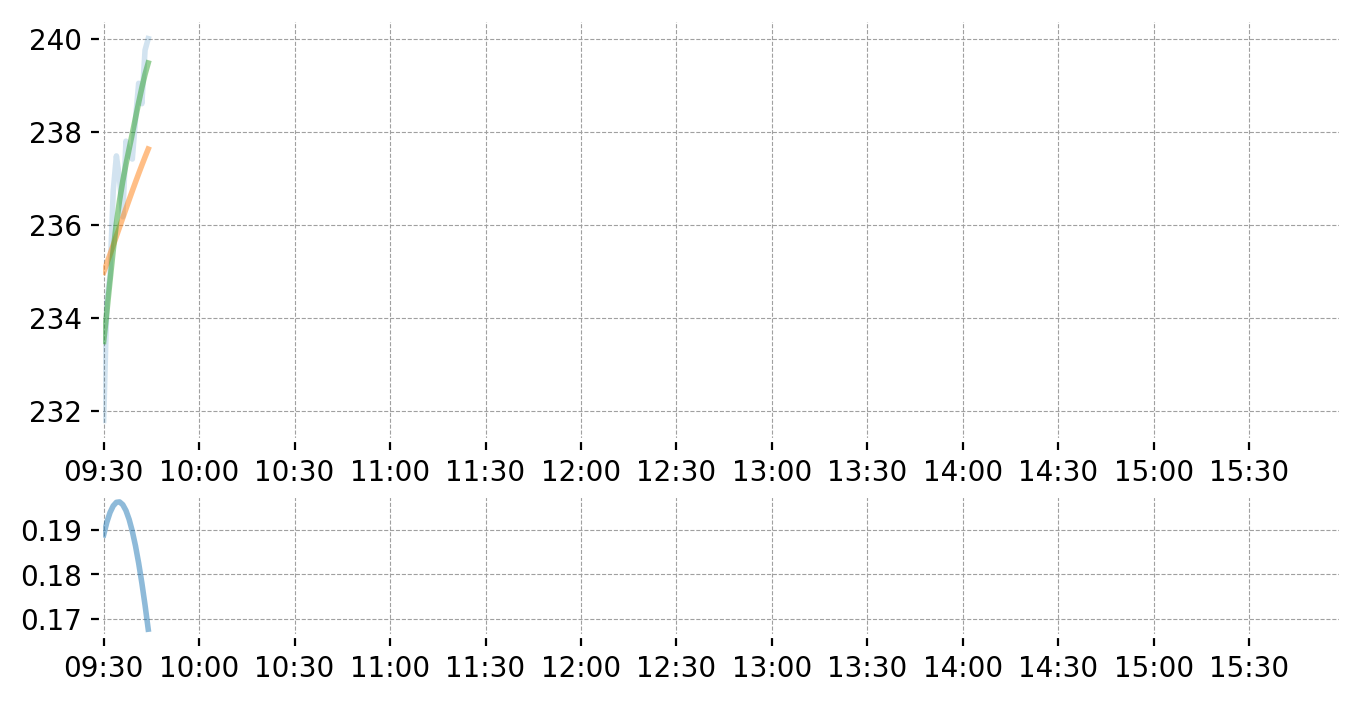

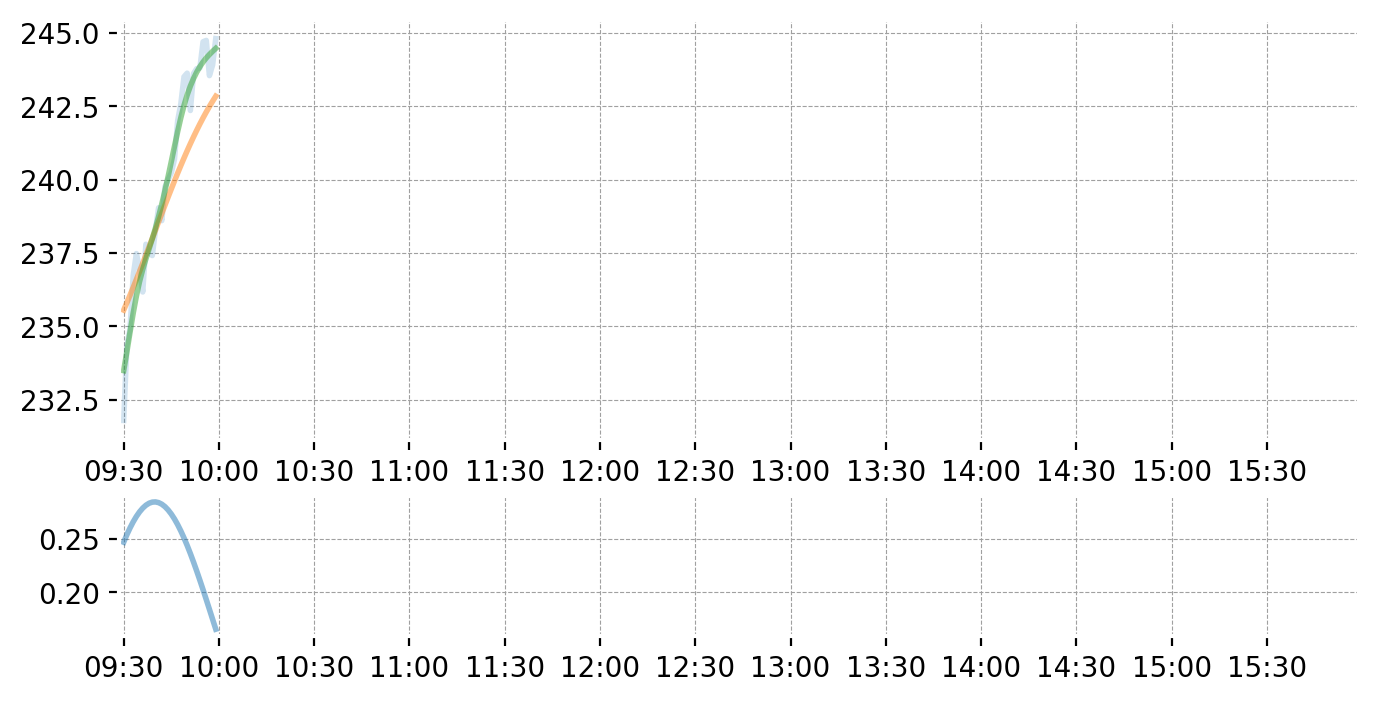

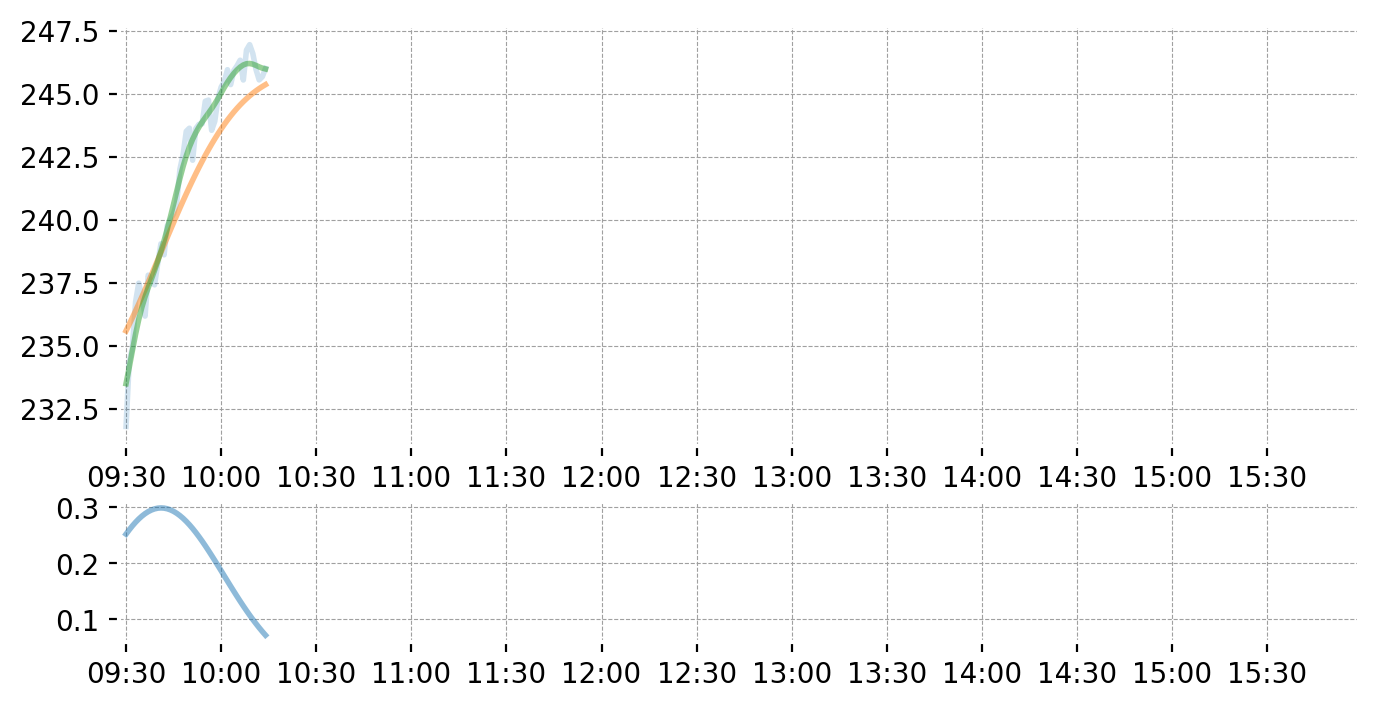

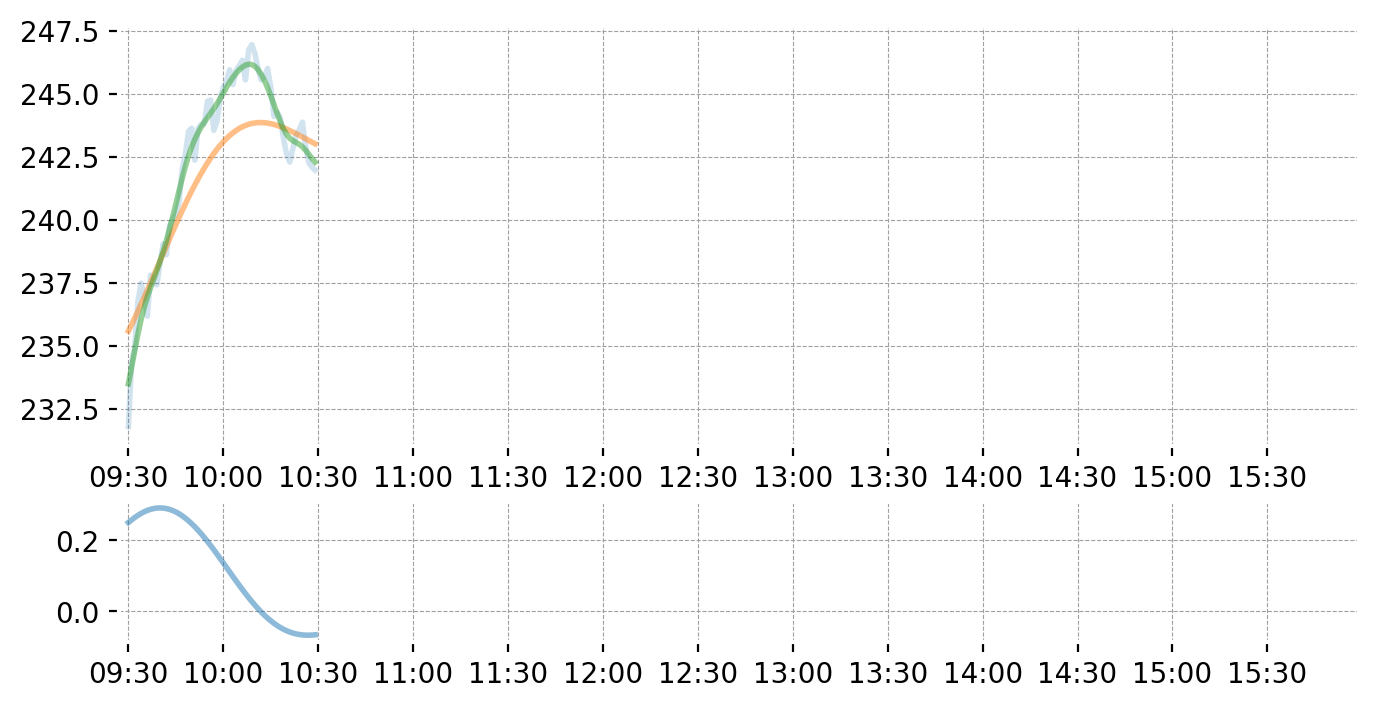

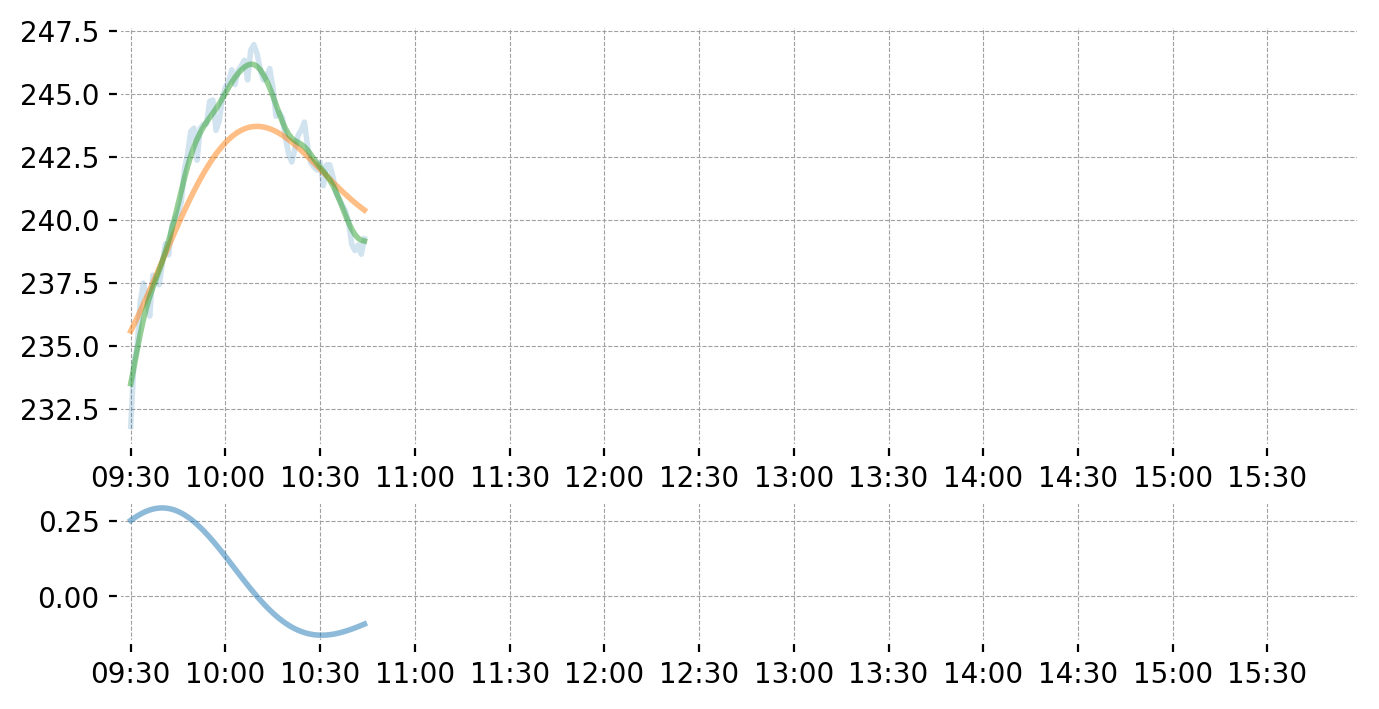

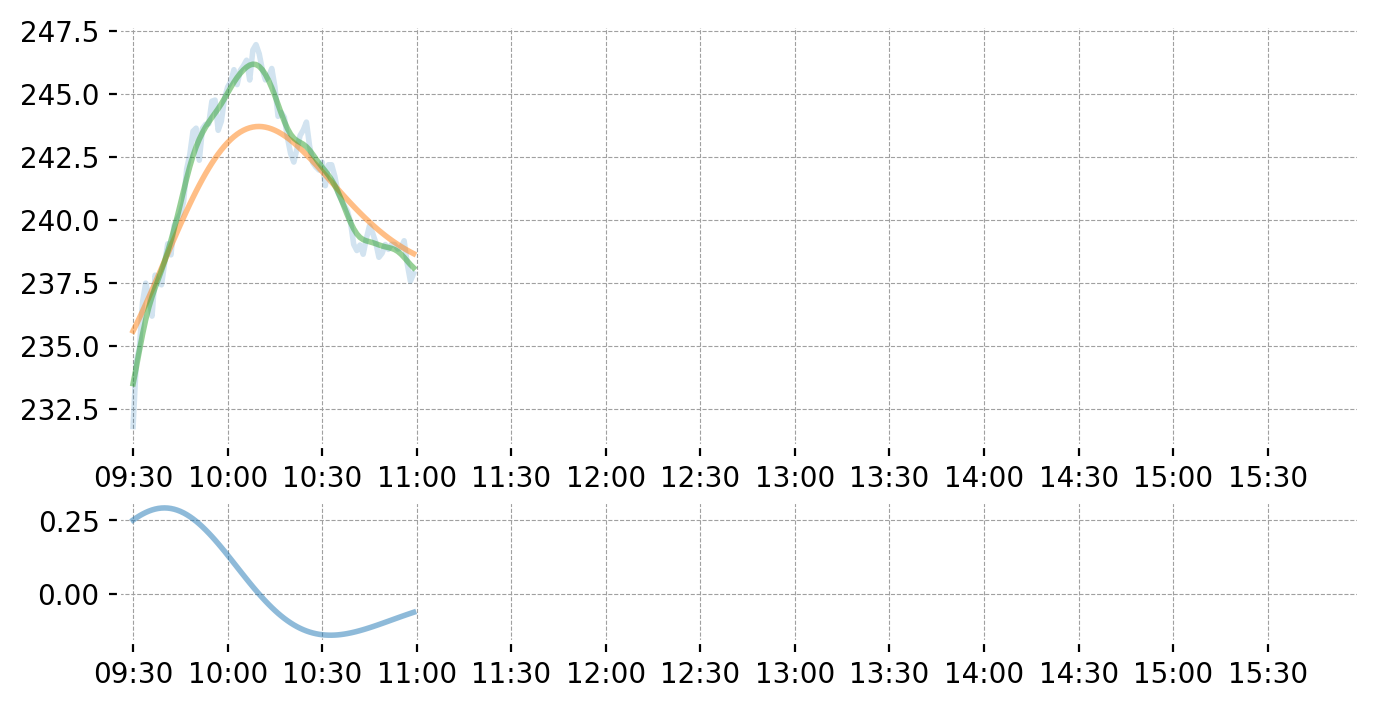

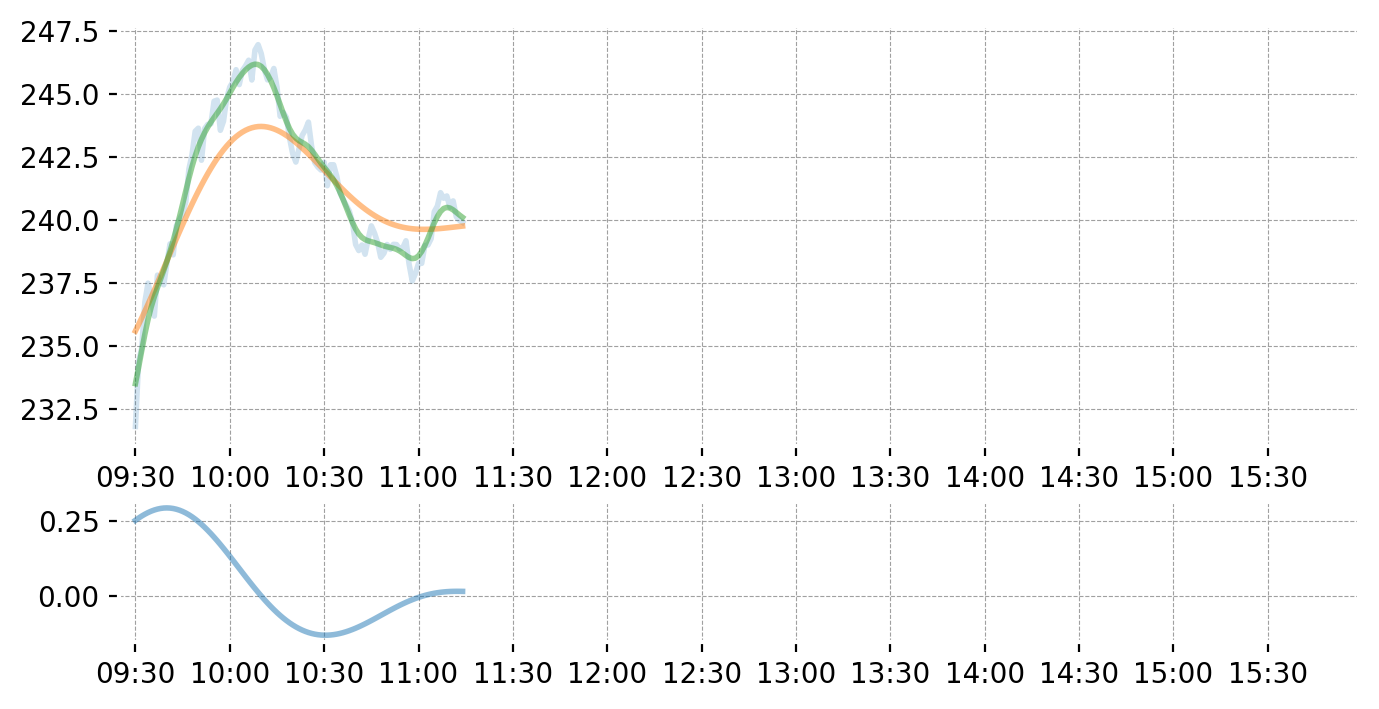

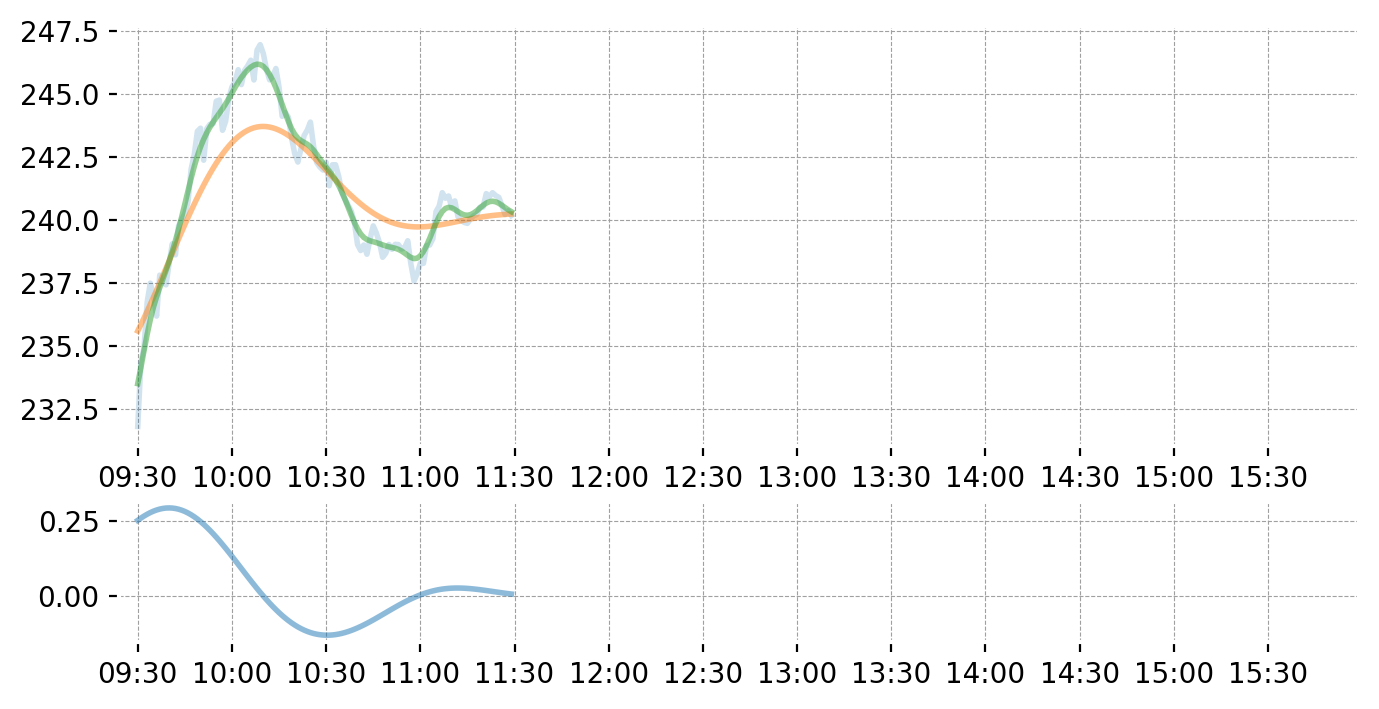

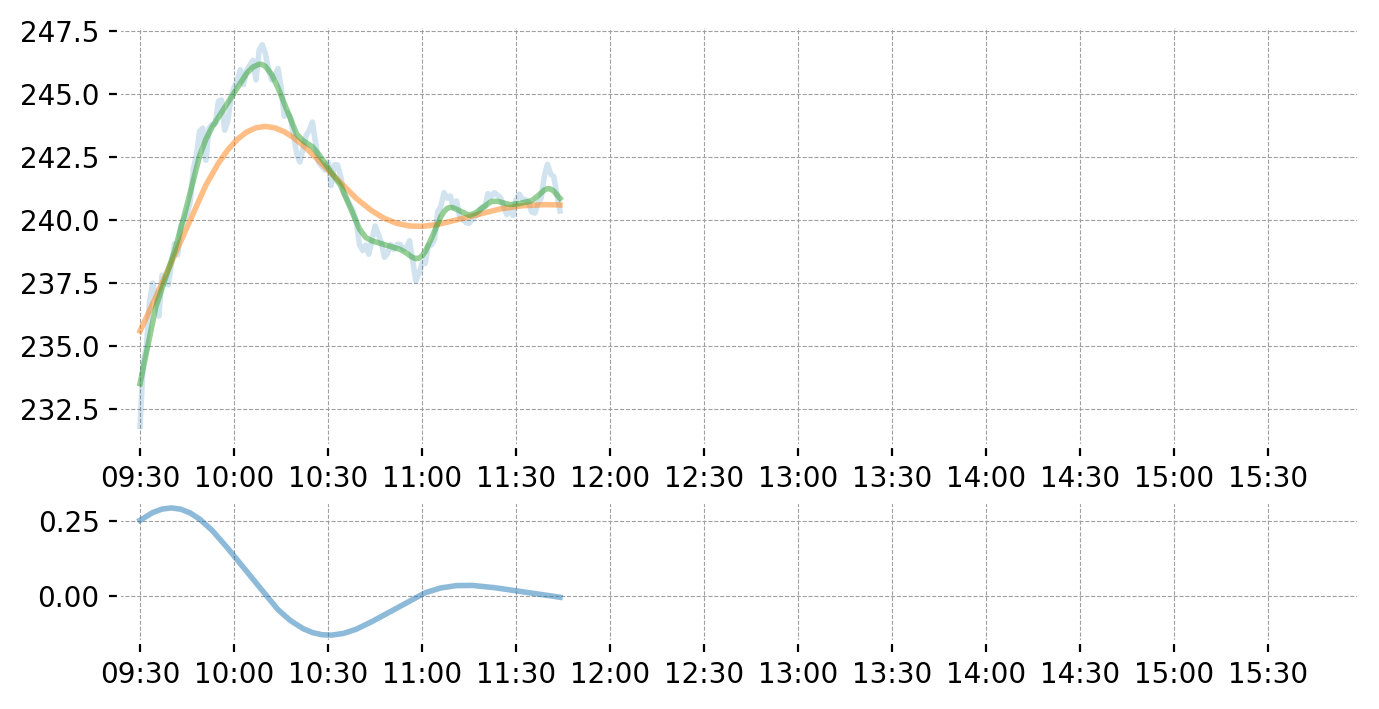

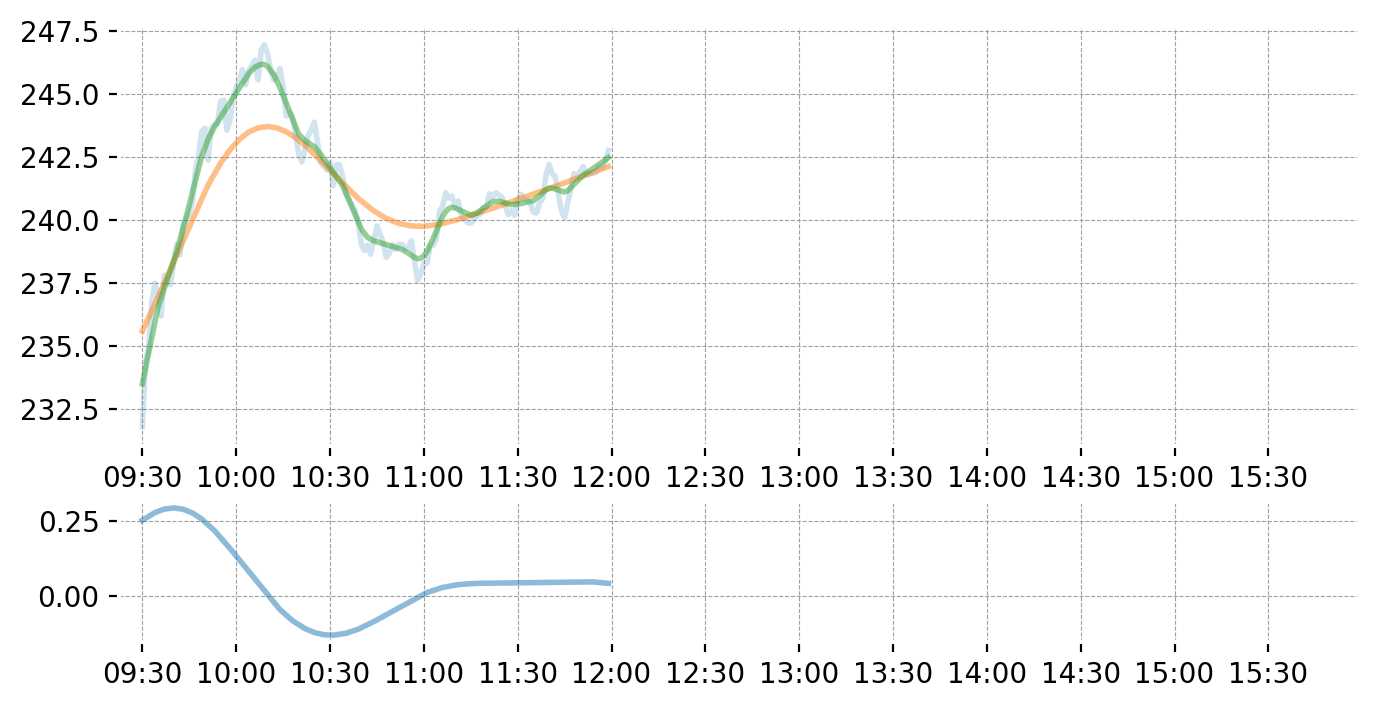

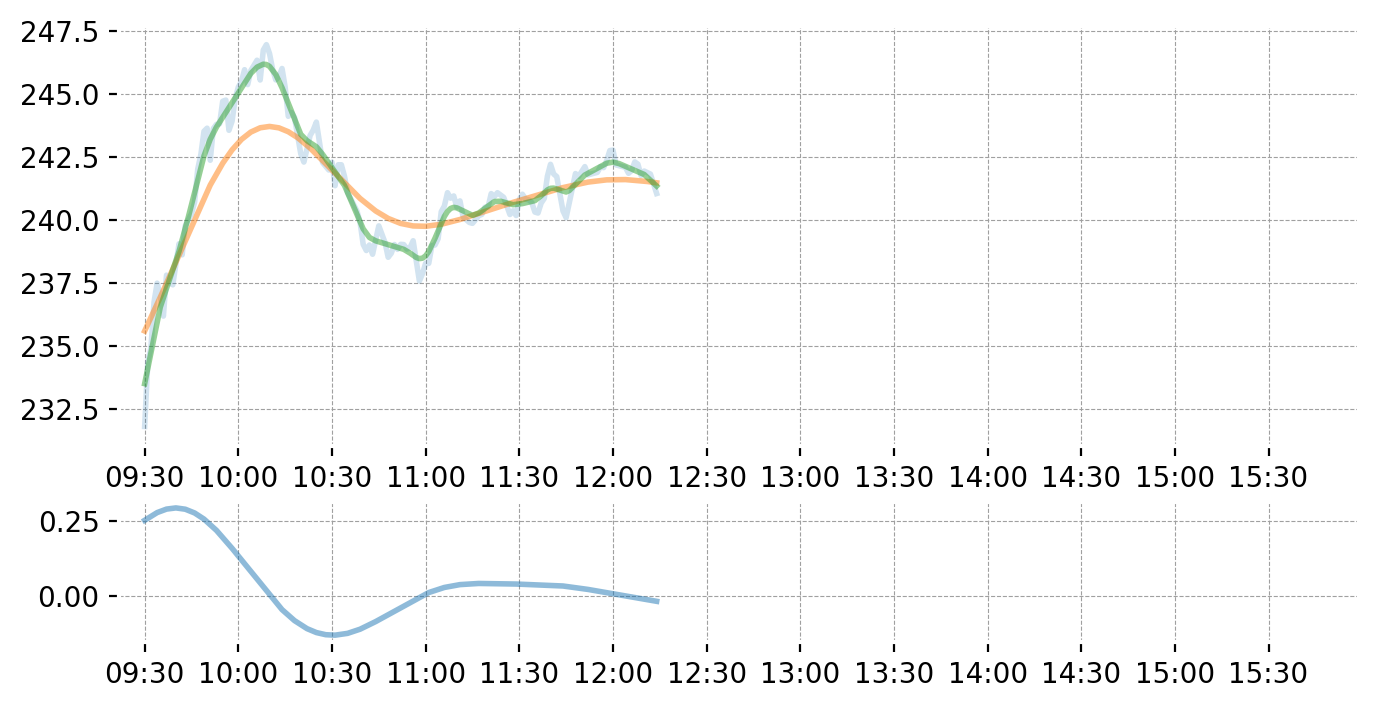

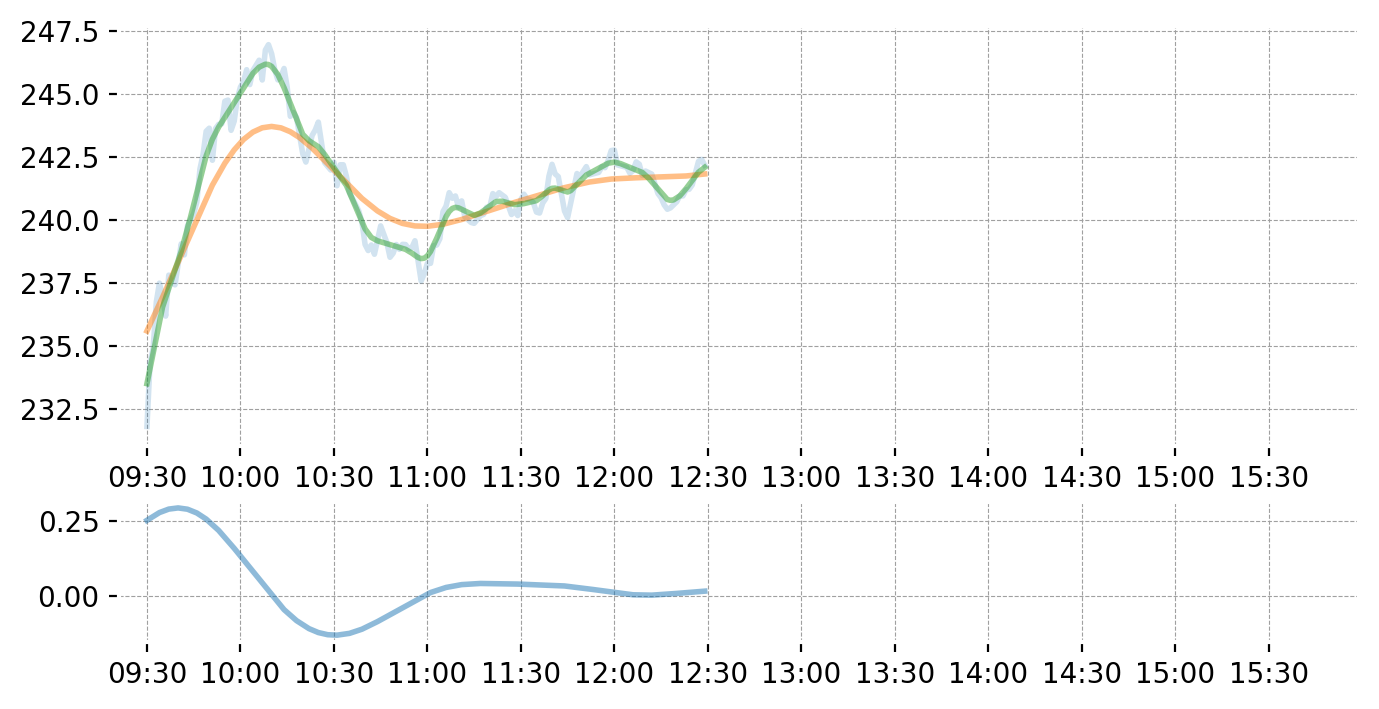

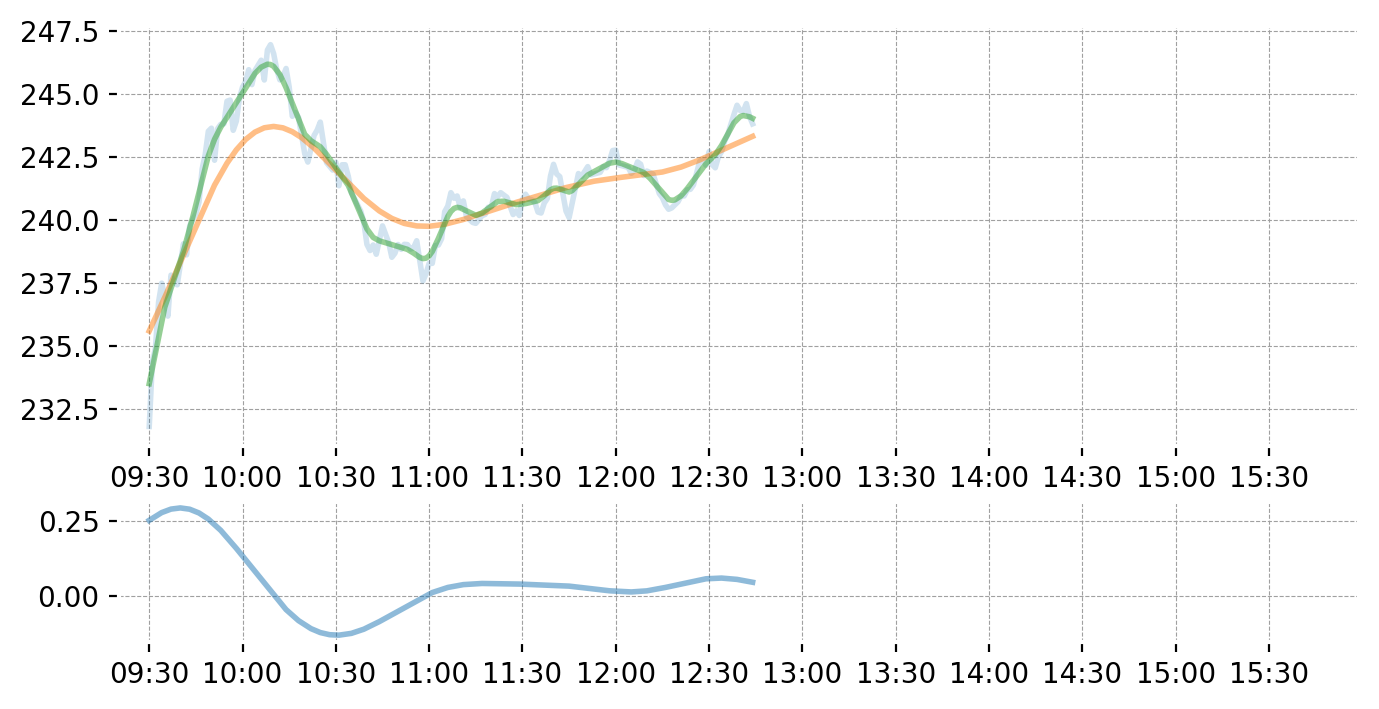

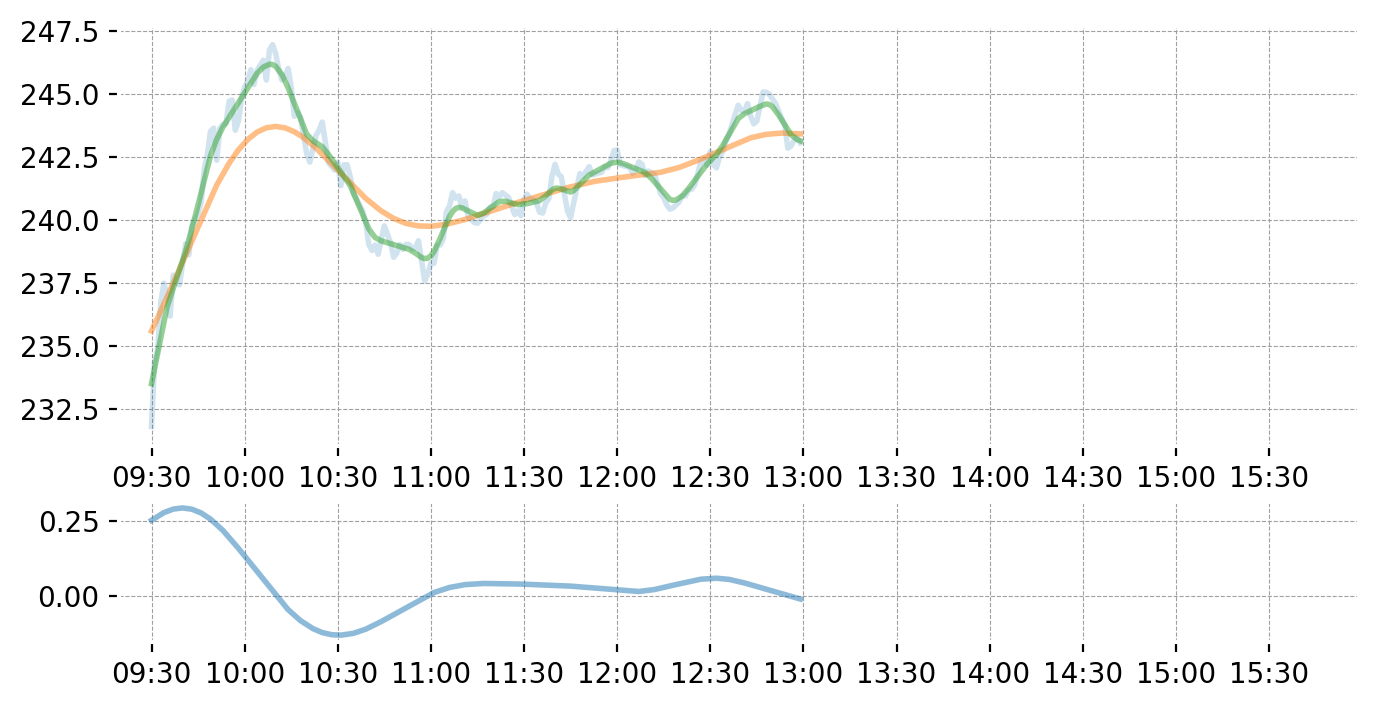

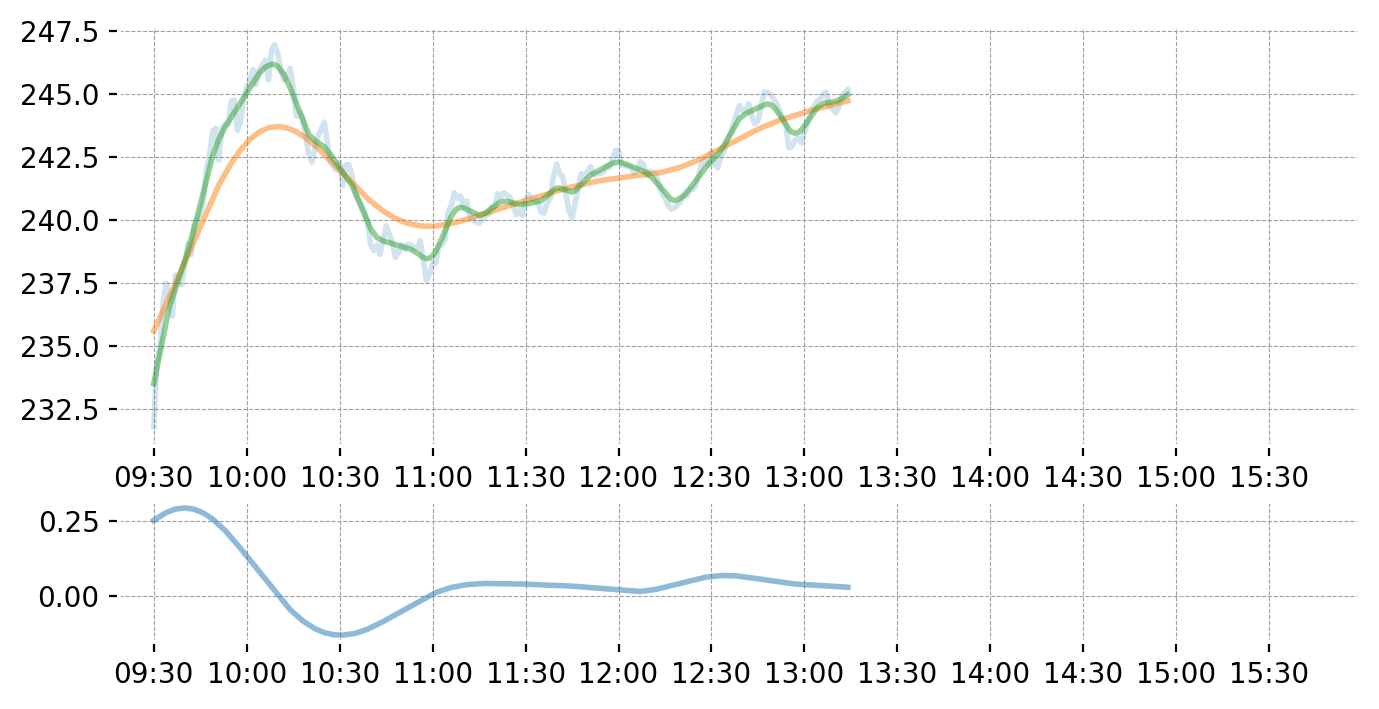

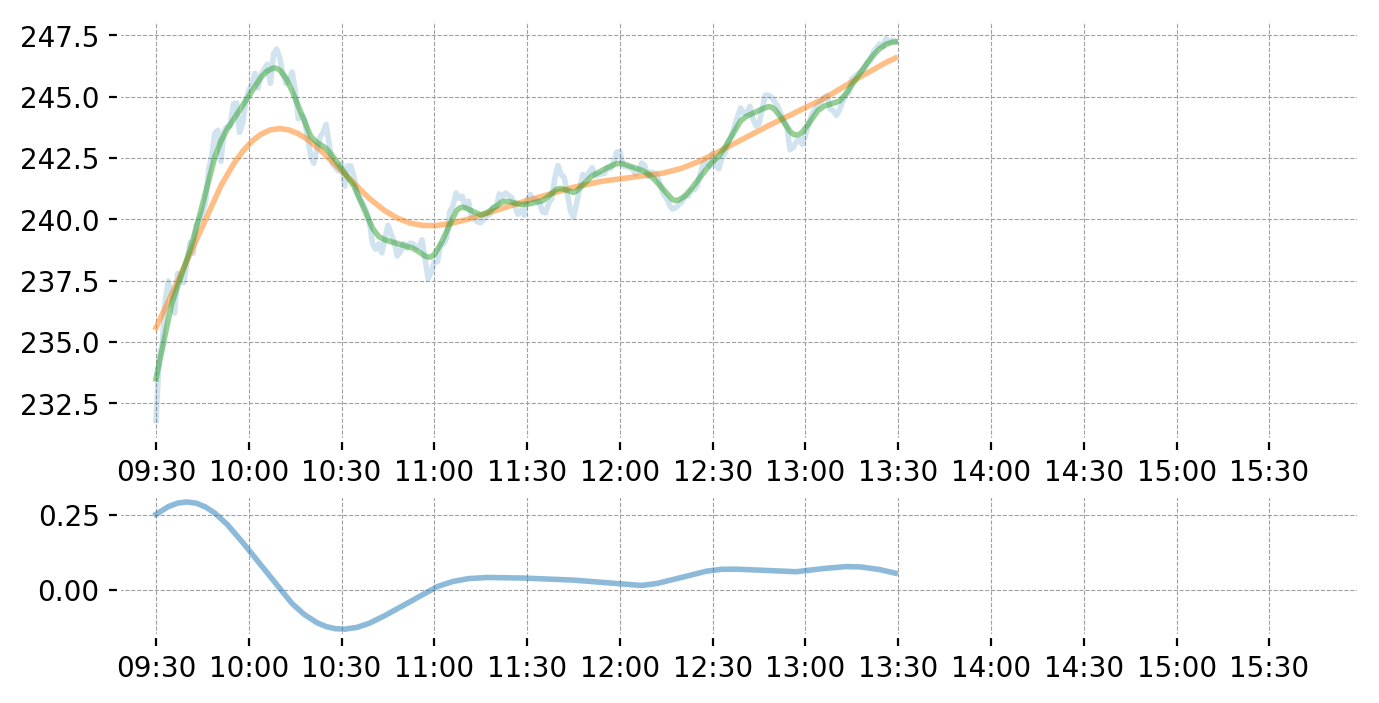

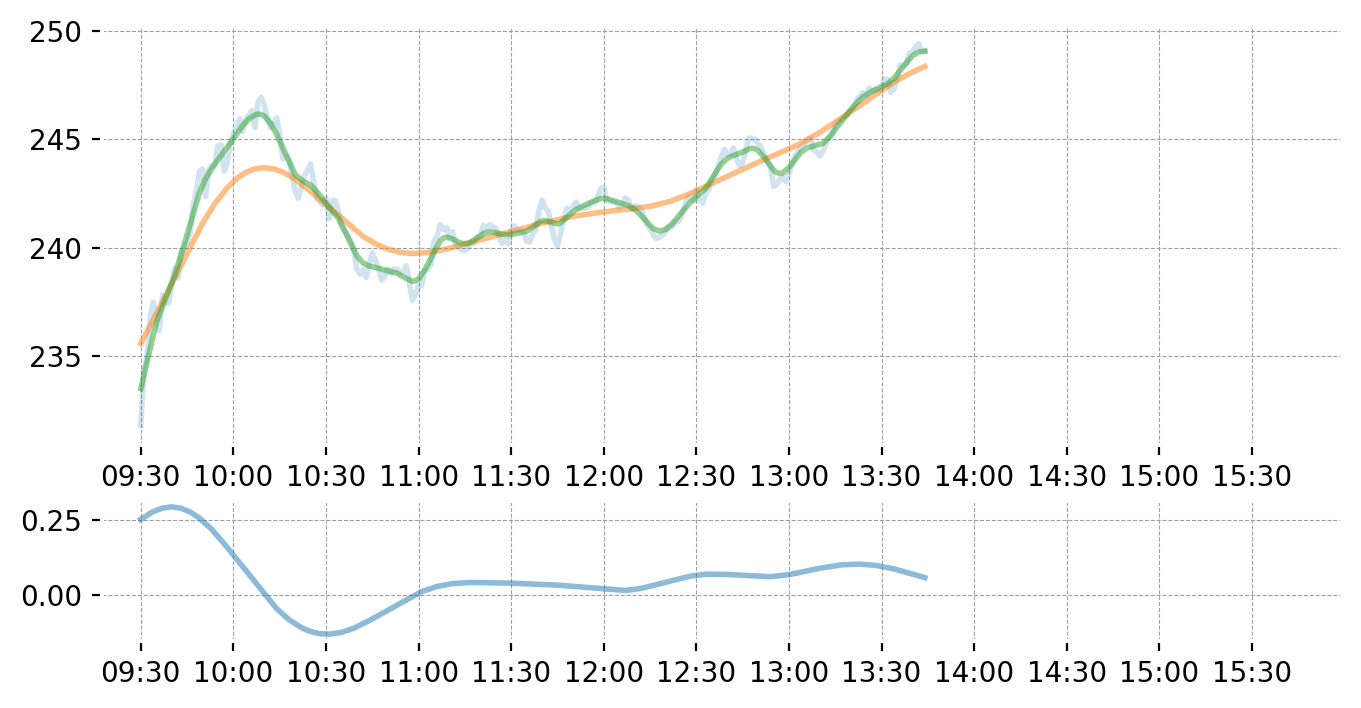

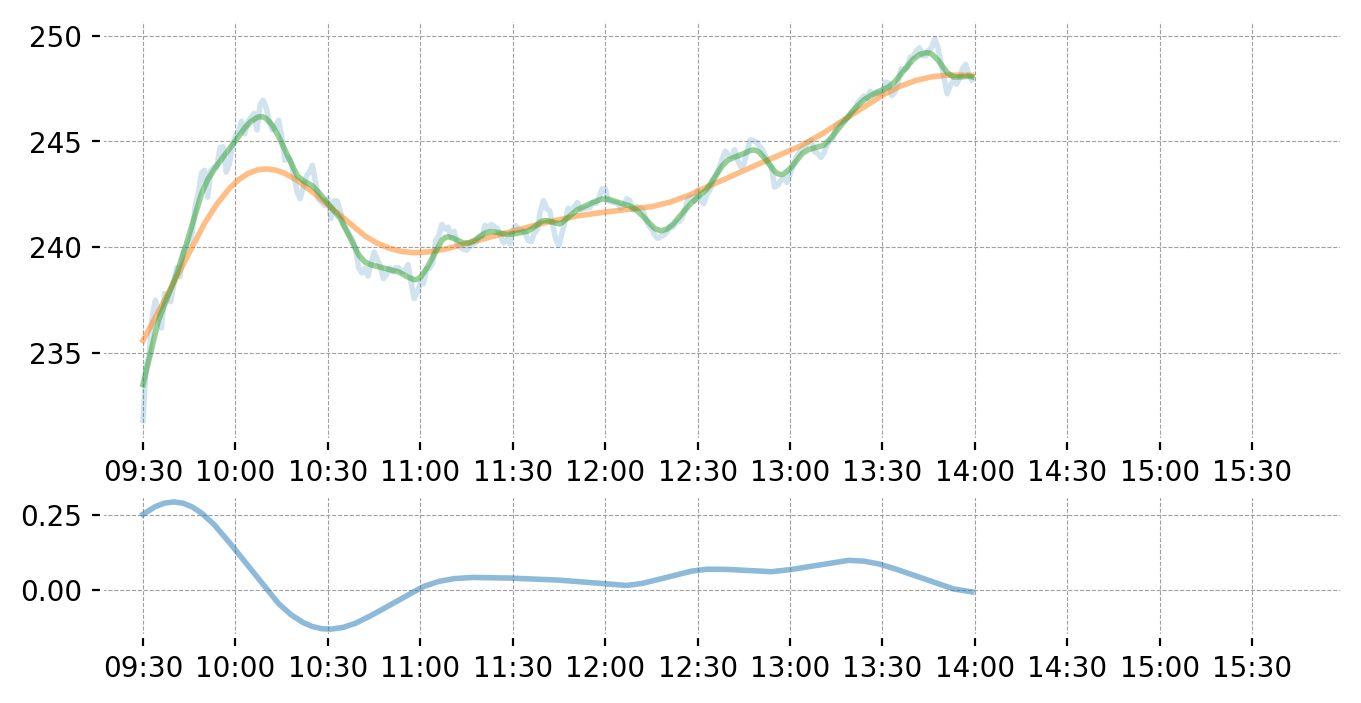

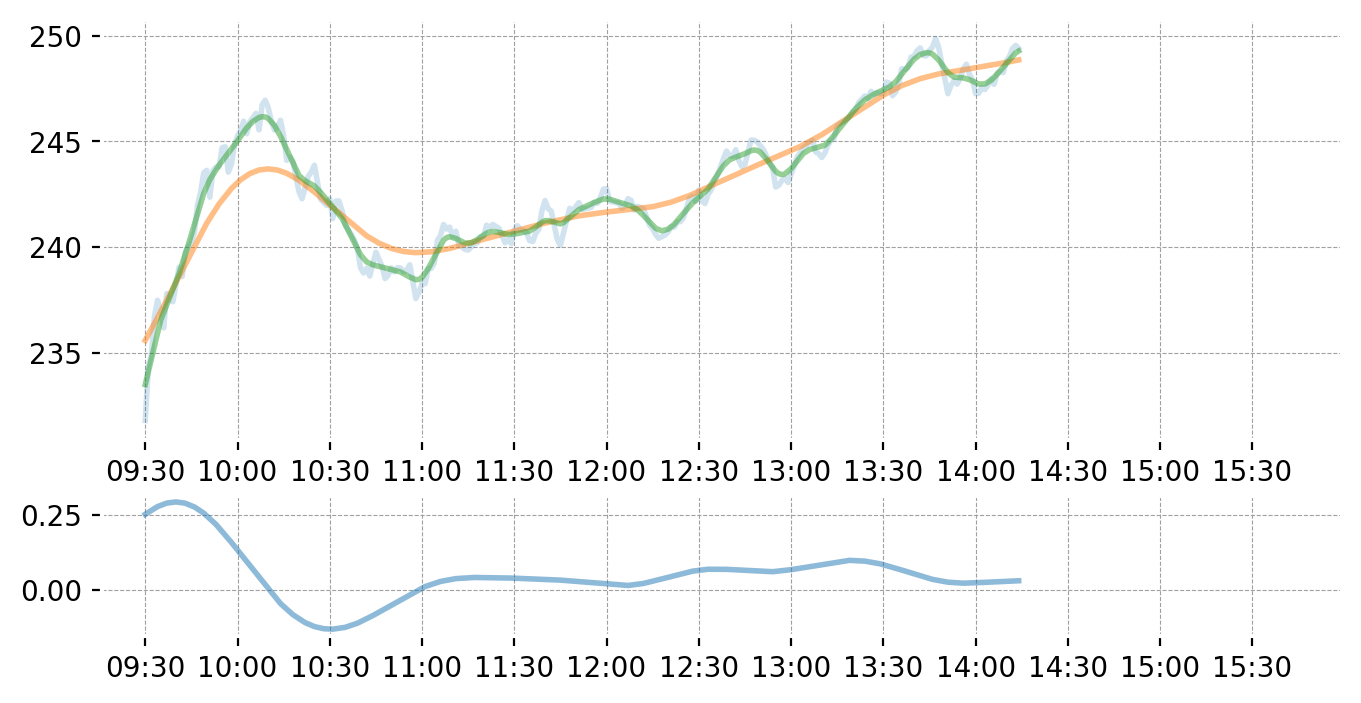

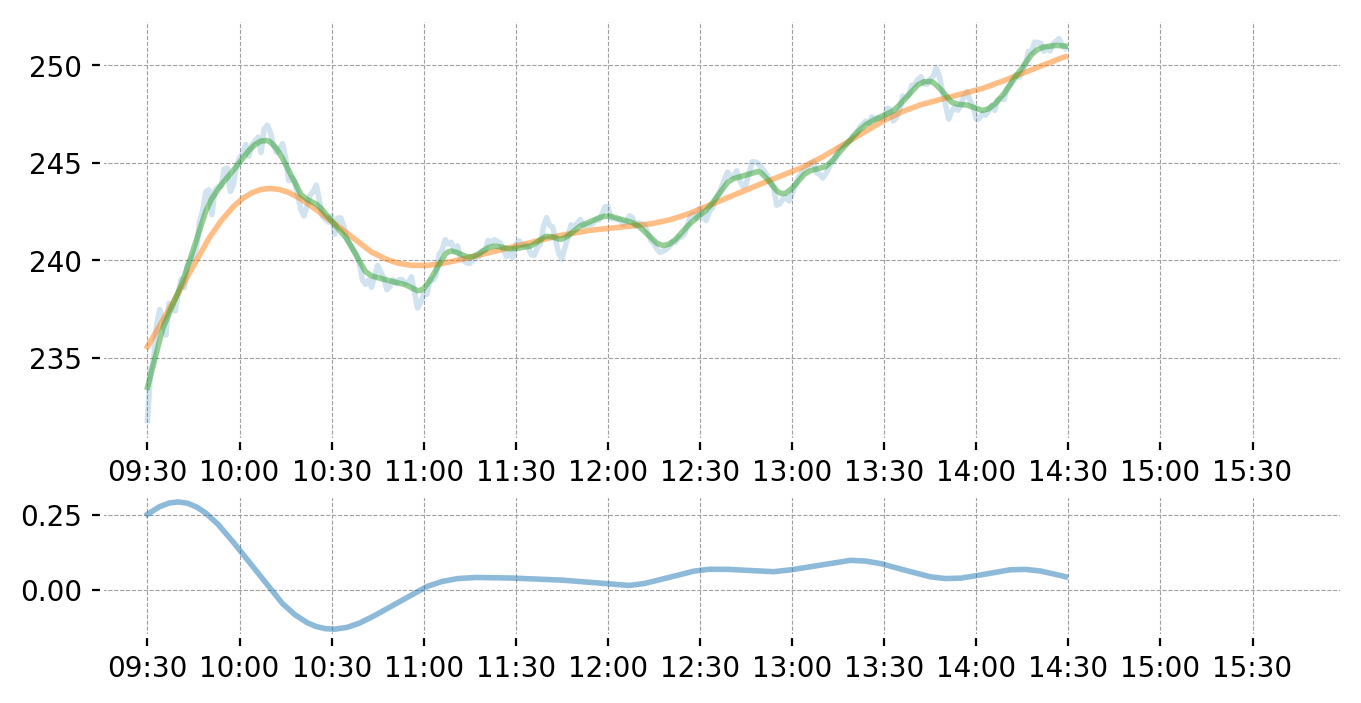

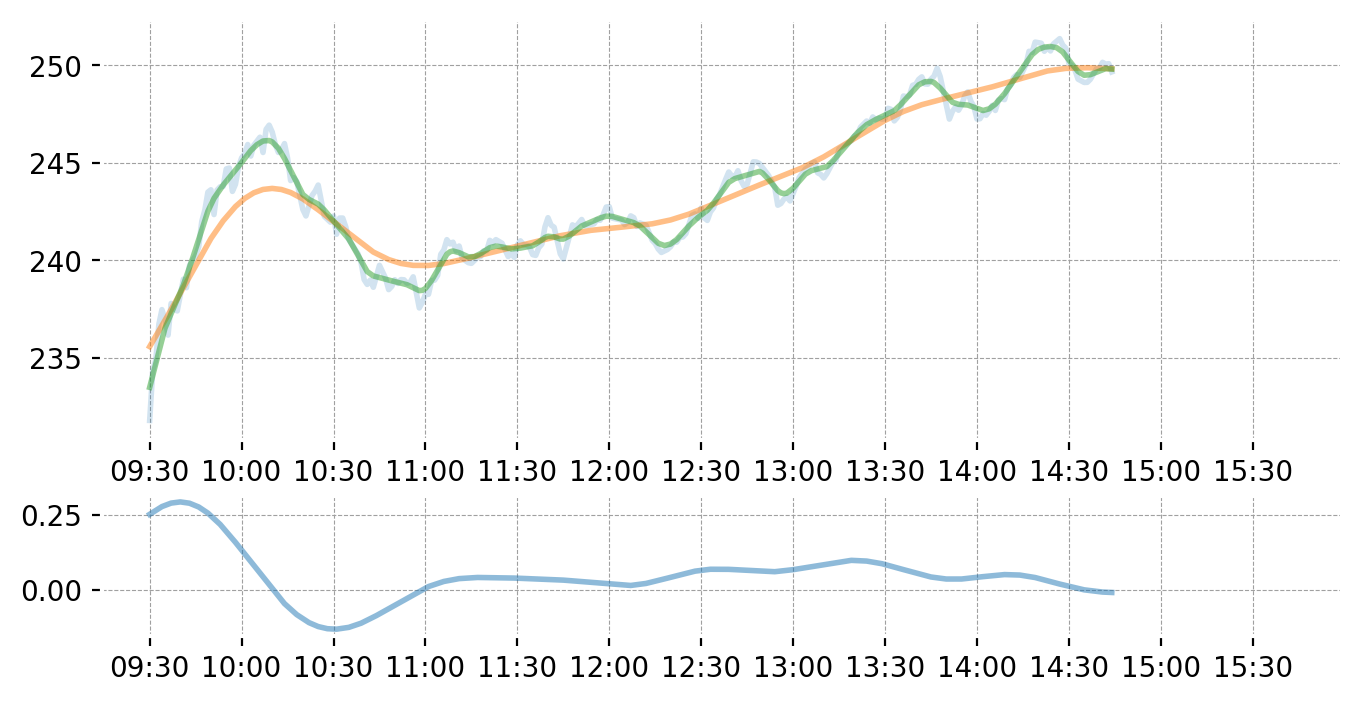

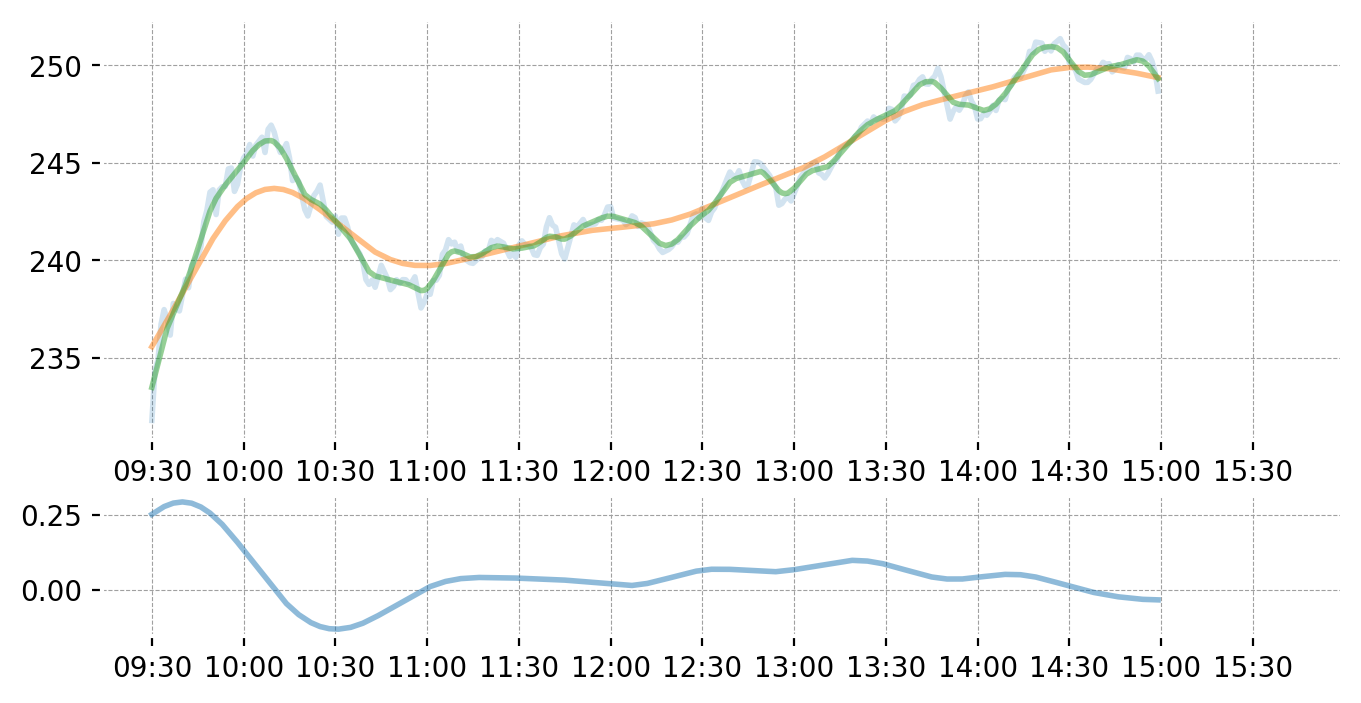

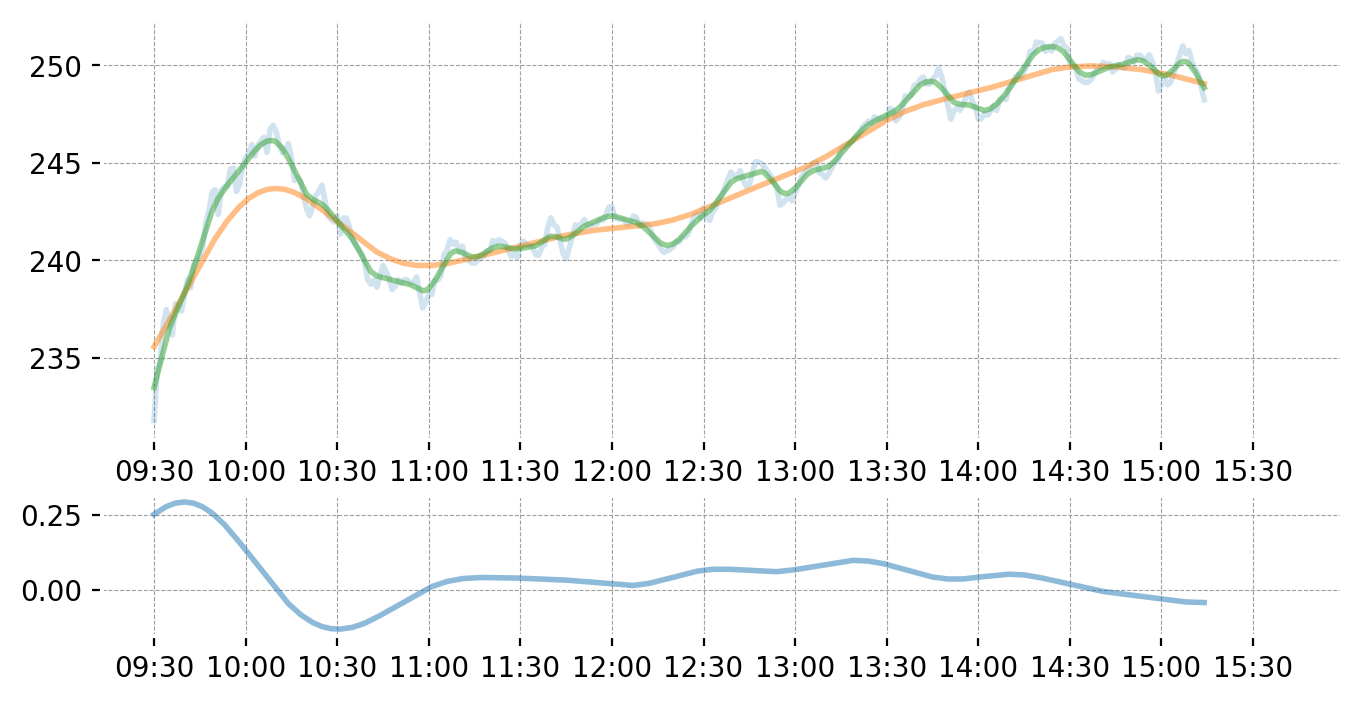

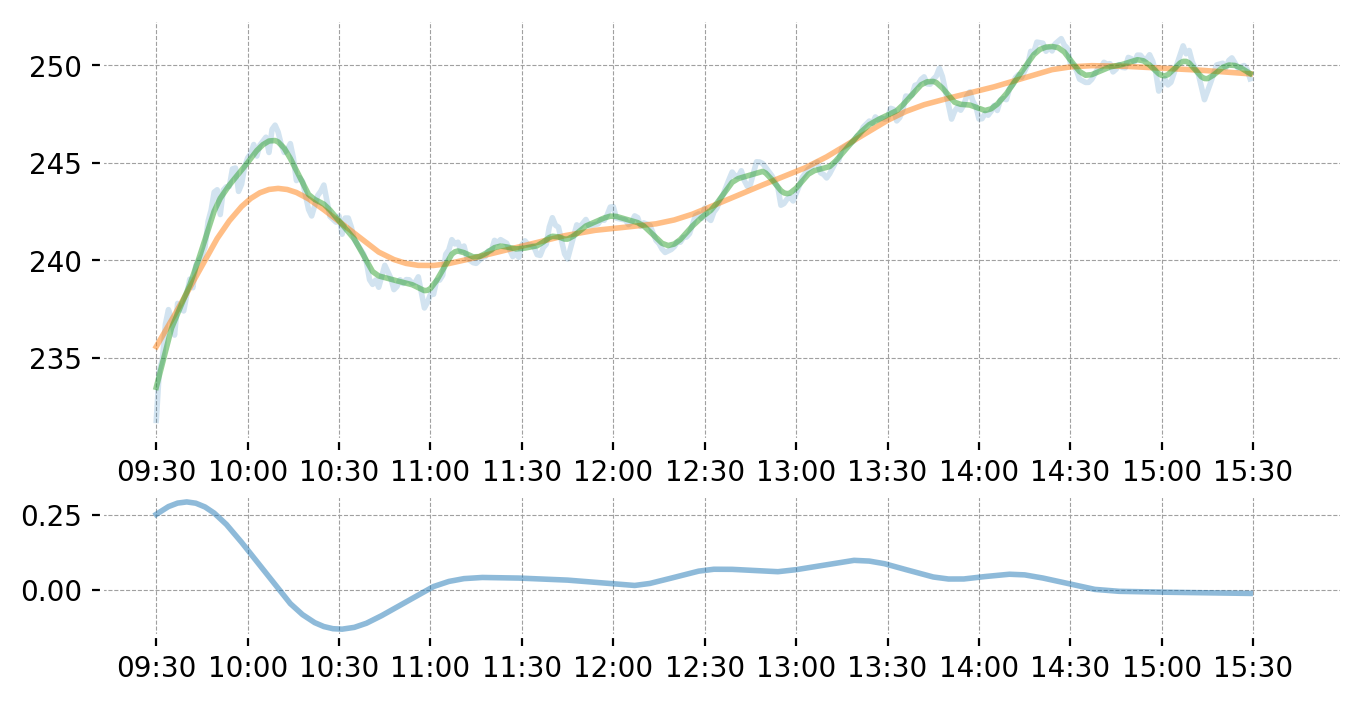

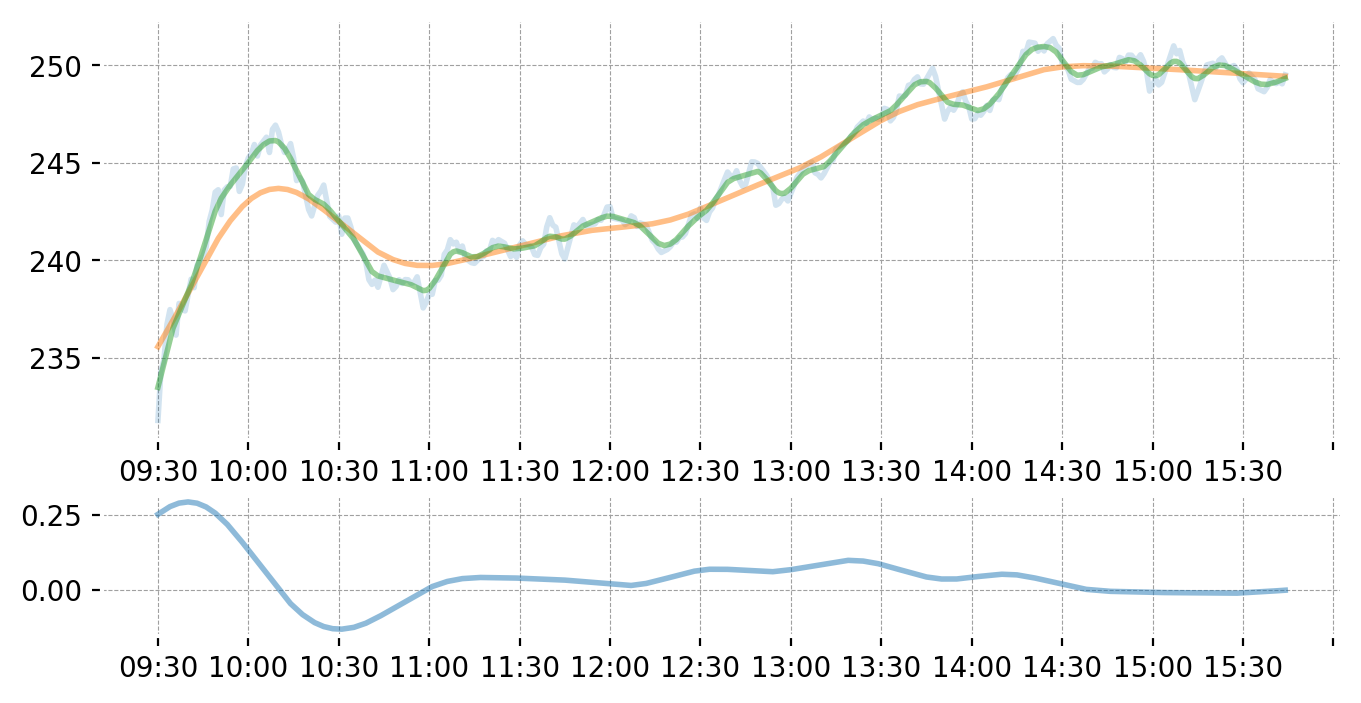

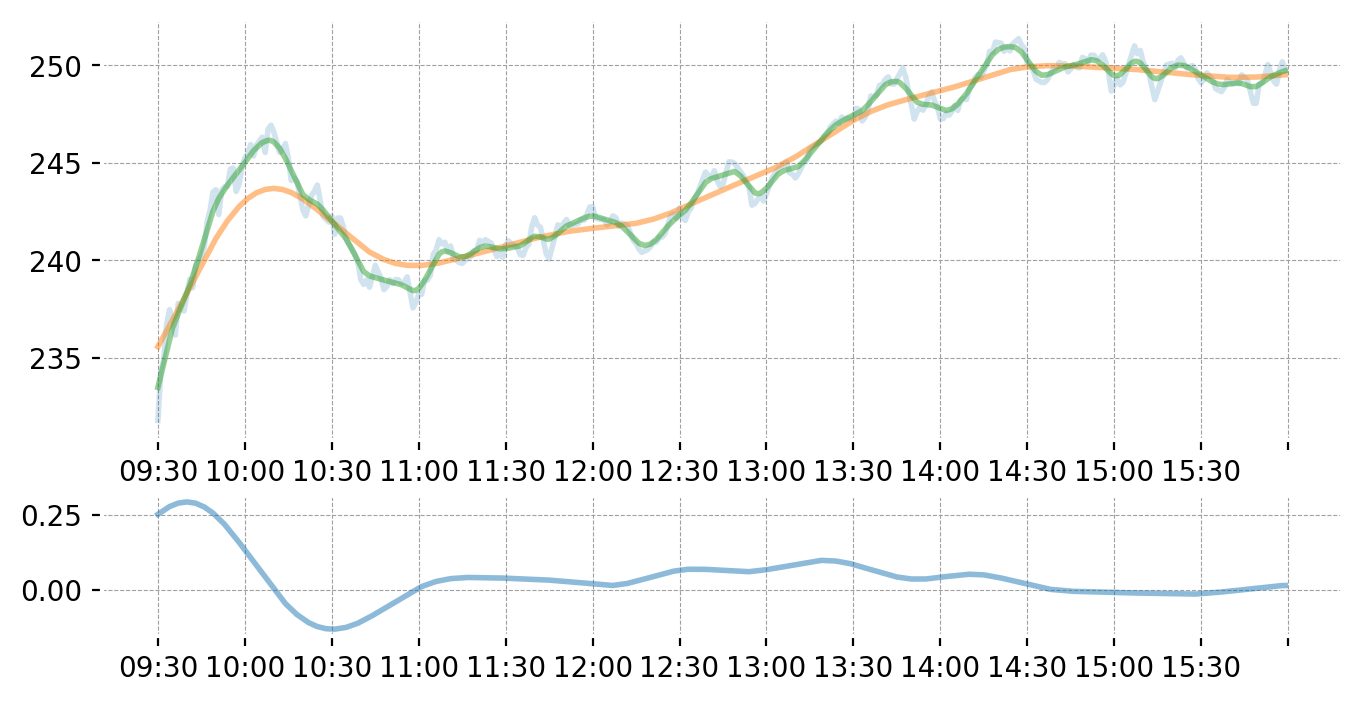

In [41]:
for i in range(15, len(vector) + 1, 15):
    running_vector = vector[:i]
    fig, axs = plt.subplots(2, 1, figsize=(8, 4), gridspec_kw={'height_ratios': [3, 1]})

    # Original vector plots
    axs[0].plot(running_vector, label=f'Original Vector (up to {i} points)', alpha=0.2)
    sigma = 16
    sm2 = gaussian_filter1d(running_vector, sigma=sigma, mode='nearest')
    axs[0].plot(sm2, label=f"sigma={sigma} (up to {i} points)", alpha=0.5)
    der2 = gaussian_filter1d(running_vector, sigma=sigma, mode='nearest', order=1)
    axs[1].plot(der2, label=f"sigma={sigma} (up to {i} points)", alpha=0.5)
    sigma = 3
    sm3 = gaussian_filter1d(running_vector, sigma=sigma, mode='nearest')
    axs[0].plot(sm3, label=f"sigma={sigma} (up to {i} points)", alpha=0.5)
    # der3 = gaussian_filter1d(running_vector, sigma=sigma, mode='nearest', order=1)
    # axs[1].plot(der3, label=f"sigma={sigma} (up to {i} points)", alpha=0.5)

    # Set the same x-ticks and x-tick labels for all subplots
    for ax in axs.flat:
        ax.set_xticks(np.arange(len(x_axis_values)))
        ax.set_xticklabels(x_axis_values.dt.strftime('%H:%M'))
        ax.xaxis.set_major_locator(ticker.MultipleLocator(30))
        ax.grid(True)

    # # Set titles and legends
    # axs[0].set_title('Original and Smoothed Vectors')
    # for ax in axs.flat:
    #     ax.legend(fontsize='small')

    # plt.tight_layout()
    plt.show()


In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(8, 4), gridspec_kw={'height_ratios': [3, 1]})
# logvector = np.log(vector)

# Original vector plots
axs[0].plot(vector, label='Original Vector', alpha=0.2)
sigma = 16
sm2 = gaussian_filter1d(vector, sigma=sigma, mode='nearest')
axs[0].plot(sm2, label=f"sigma={sigma}", alpha=0.5)
der2 = gaussian_filter1d(vector, sigma=sigma, mode='nearest', order=1)
axs[1].plot(der2, label=f"sigma={sigma}", alpha=0.5)
sigma = 3
sm3 = gaussian_filter1d(vector, sigma=sigma, mode='nearest')
axs[0].plot(sm3, label=f"sigma={sigma}", alpha=0.5)
der3 = gaussian_filter1d(vector, sigma=sigma, mode='nearest', order=1)
axs[1].plot(der3, label=f"sigma={sigma}", alpha=0.5)

# Set the same x-ticks and x-tick labels for all subplots
for ax in axs.flat:
    ax.set_xticks(np.arange(len(x_axis_values)))
    ax.set_xticklabels(x_axis_values.dt.strftime('%H:%M'))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(30))
    ax.grid(True)

# Set titles and legends
axs[0].set_title('Original and Smoothed Vectors')
for ax in axs.flat:
    ax.legend(fontsize='small')

plt.tight_layout()
plt.show()


Compare log-vector and plain vector

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw={'height_ratios': [3, 1]})
logvector = np.log(vector)

# Original vector plots
axs[0, 0].plot(vector, label='Original Vector', alpha=0.2)
sigma = 16
sm2 = gaussian_filter1d(vector, sigma=sigma, mode='nearest')
axs[0, 0].plot(sm2, label=f"sigma={sigma}", alpha=0.5)
der2 = gaussian_filter1d(vector, sigma=sigma, mode='nearest', order=1)
axs[1, 0].plot(der2, label=f"sigma={sigma}", alpha=0.5)
sigma = 3
sm3 = gaussian_filter1d(vector, sigma=sigma, mode='nearest')
axs[0, 0].plot(sm3, label=f"sigma={sigma}", alpha=0.5)
der3 = gaussian_filter1d(vector, sigma=sigma, mode='nearest', order=1)
axs[1, 0].plot(der3, label=f"sigma={sigma}", alpha=0.5)

# Log vector plots
axs[0, 1].plot(logvector, label='Log Vector', alpha=0.2)
sigma = 16
sm2_log = gaussian_filter1d(logvector, sigma=sigma, mode='nearest')
axs[0, 1].plot(sm2_log, label=f"sigma={sigma}", alpha=0.5)
der2_log = gaussian_filter1d(logvector, sigma=sigma, mode='nearest', order=1)
axs[1, 1].plot(der2_log, label=f"sigma={sigma}", alpha=0.5)
sigma = 3
sm3_log = gaussian_filter1d(logvector, sigma=sigma, mode='nearest')
axs[0, 1].plot(sm3_log, label=f"sigma={sigma}", alpha=0.5)
der3_log = gaussian_filter1d(logvector, sigma=sigma, mode='nearest', order=1)
axs[1, 1].plot(der3_log, label=f"sigma={sigma}", alpha=0.5)

# Set the same x-ticks and x-tick labels for all subplots
for ax in axs.flat:
    ax.set_xticks(np.arange(len(x_axis_values)))
    ax.set_xticklabels(x_axis_values.dt.strftime('%H:%M'))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(30))
    ax.grid(True)

# Set titles and legends
axs[0, 0].set_title('Original and Smoothed Vectors')
axs[0, 1].set_title('Log and Smoothed Log Vectors')
for ax in axs.flat:
    ax.legend(fontsize='small')

plt.tight_layout()
plt.show()


In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(9, 6), gridspec_kw={'height_ratios': [3, 1]})

axs[0].plot(vector, label='Original Vector', alpha=0.2)

sigma = 16
sm2 = gaussian_filter1d(vector, sigma=sigma, mode='nearest')
axs[0].plot(sm2, label=f"sigma={sigma}", alpha=0.5)

der2 = gaussian_filter1d(vector, sigma=sigma, mode='nearest', order=1)
axs[1].plot(der2, label=f"sigma={sigma}", alpha=0.5)

sigma = 3
sm3 = gaussian_filter1d(vector, sigma=sigma, mode='nearest')
axs[0].plot(sm3, label=f"sigma={sigma}", alpha=0.5)

der3 = gaussian_filter1d(vector, sigma=sigma, mode='nearest', order=1)
axs[1].plot(der3, label=f"sigma={sigma}", alpha=0.5)


# Set the same x-ticks and x-tick labels for both subplots
axs[0].set_xticks(np.arange(len(x_axis_values)))
axs[0].set_xticklabels(x_axis_values.dt.strftime('%H:%M'))
axs[0].xaxis.set_major_locator(ticker.MultipleLocator(30))

axs[1].set_xticks(np.arange(len(x_axis_values)))
axs[1].set_xticklabels(x_axis_values.dt.strftime('%H:%M'))
axs[1].xaxis.set_major_locator(ticker.MultipleLocator(30))

axs[0].set_title('Original and Smoothed Vectors')
axs[0].grid(True)

# Show legends with small fonts
axs[0].legend(fontsize='small')
axs[1].legend(fontsize='small')

plt.show()


Is gaussian_filter1d() linear?

In [ ]:
scaling_factor = 7.0 # some random scaling factor
sigma = 3

smoothed_vector = gaussian_filter1d(vector, sigma=sigma)
smoothed_vector_der = gaussian_filter1d(vector, sigma=sigma, order=1) # take derivative

a = gaussian_filter1d(vector*scaling_factor, sigma=sigma) / smoothed_vector # scale input
a_der = gaussian_filter1d(vector*scaling_factor, sigma=sigma, order=1) / smoothed_vector_der

b = np.ones_like(vector) * scaling_factor
all( np.isclose(a, b, rtol=1e-9) )
all( np.isclose(a_der, b, rtol=1e-9) )


In [ ]:
start_time = pd.to_datetime('2024-11-08 09:30:00-05:00')

Compare effect of different window size vs sigma

In [113]:
sym = 'SPY'
date = f'{datetime.datetime.now()+datetime.timedelta(days=0):%Y%m%d}'
filename = f'{sym}_1m_{date}.csv'
bars_df = pd.read_csv(rf'.\data\{filename}', parse_dates=['date']).rename(columns={'open_': 'open'})

# Filter bars_df for the time range from 9:30am to 4:00pm
m1 = (bars_df['date'].dt.time >= datetime.time(9, 30)) & (bars_df['date'].dt.time <= datetime.time(16, 0))
df = bars_df[m1].loc[:, ['open', 'high', 'low', 'close', 'average', 'date']]
vector_full = np.asarray(df['average'])
# x_values: NDArray = df.index.values

In [ ]:
count_der1 = count_der2 = 0
for i in range(1, vector_full.size + 1):
    running_vector1 = vector[:i]
    sigma = 24
    smoothed1 = gaussian_filter1d(running_vector1, sigma=sigma, mode='nearest')
    der1_1 = gaussian_filter1d(running_vector1, sigma=sigma, mode='nearest', order=1)
    der2_1 = gaussian_filter1d(running_vector1, sigma=sigma, mode='nearest', order=2)

    running_vector2 = running_vector1[-60:]
    # sigma = 16
    smoothed2 = gaussian_filter1d(running_vector2, sigma=sigma, mode='nearest')
    der1_2 = gaussian_filter1d(running_vector2, sigma=sigma, mode='nearest', order=1)
    der2_2 = gaussian_filter1d(running_vector2, sigma=sigma, mode='nearest', order=2)

    if der1_1[-1]*der1_2[-1] < 0:
        count_der1 += 1
        # print(f"{df.date.iloc[i-1]:%H:%M}, {vector[i-1]}, {len(running_vector1)}, smoothed1={smoothed1[-1]:.4f}, smoothed2={smoothed2[-1]:.4f}, der1={der1[-1]:.4f}, der2={der2[-1]:.4f}, {der1[-1]*der2[-1]:+.1f}")
    if der2_1[-1]*der2_2[-1] < 0:
        count_der2 += 1
print(f"count_der1={count_der1/vector_full.size:.4%}, count_der2={count_der2/vector_full.size:.4%}")

Compare effect of different sigma

In [ ]:
count_der1 = count_der2 = 0

for i in range(1, vector_full.size + 1):
    running_vector1 = vector[:i]
    sigma = 8
    smoothed1 = gaussian_filter1d(running_vector1, sigma=sigma, mode='nearest')
    der1_1 = gaussian_filter1d(running_vector1, sigma=sigma, mode='nearest', order=1)
    der2_1 = gaussian_filter1d(running_vector1, sigma=sigma, mode='nearest', order=2)

    sigma = 2
    smoothed2 = gaussian_filter1d(running_vector1, sigma=sigma, mode='nearest')
    der1_2 = gaussian_filter1d(running_vector1, sigma=sigma, mode='nearest', order=1)
    der2_2 = gaussian_filter1d(running_vector1, sigma=sigma, mode='nearest', order=2)

    print(f"{df.date.iloc[i-1]:%H:%M}, {vector[i-1]}, {len(running_vector1)}, smoothed1={smoothed1[-1]:.4f}, smoothed2={smoothed2[-1]:.4f}, der1_1={der1_1[-1]:.4f}, der1_2={der1_2[-1]:.4f}, {der2_1[-1]:.4f} {der2_2[-1]:.4f}")
    if der1_1[-1]*der1_2[-1] < 0:
        count_der1 += 1
        # print(f"{df.date.iloc[i-1]:%H:%M}, {vector[i-1]}, {len(running_vector1)}, smoothed1={smoothed1[-1]:.4f}, smoothed2={smoothed2[-1]:.4f}, der1={der1[-1]:.4f}, der2={der2[-1]:.4f}, {der1[-1]*der2[-1]:+.1f}")
        # print(f"{df.date.iloc[i-1]:%H:%M}, {vector[i-1]}, {len(running_vector1)}, smoothed1={smoothed1[-1]:.4f}, smoothed2={smoothed2[-1]:.4f}, der1={der1[-1]:.4f}, der2={der2[-1]:.4f}, {der1[-1]*der2[-1]:+.1f}")
    if der2_1[-1]*der2_2[-1] < 0:
        count_der2 += 1
print(f"count_der1={count_der1/vector_full.size:.4%}, count_der2={count_der2/vector_full.size:.4%}")


In [ ]:
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

def onBarUpdate(bars, hasNewBar):
    print(hasNewBar)
    plt.close()
    plot = util.barplot(bars)
    clear_output(wait=True)
    display(plot)

bars.updateEvent += onBarUpdate

# ib.sleep(100)
# ib.cancelHistoricalData(bars)

In [ ]:
def fmt_elapsed_time(elapsed_time: float) -> str:
    if elapsed_time >= 1:
        s = f"{elapsed_time:.2f} s"
    elif elapsed_time >= 1e-3:
        s = f"{elapsed_time * 1e3:.2f} ms"
    elif elapsed_time >= 1e-6:
        s = f"{elapsed_time * 1e6:.2f} µs"
    else:
        s = f"{elapsed_time * 1e9:.2f} ns"
    return s

# Example usage
elapsed_time = 0.00035004862362757927  # Replace with actual elapsed time
print(fmt_elapsed_time(elapsed_time))